In [8]:
from __future__ import annotations

from pathlib import Path
import math

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import pandas as pd

ROOT_DIR = Path("Fig4") if Path("Fig4").exists() else Path(".")
OBS_DIR = ROOT_DIR / "data/station_wspd_wdir/results_obs_newT"
SIM_DIR = ROOT_DIR / "data/station_wspd_wdir/results_sim_newT"
OUT_DIR = ROOT_DIR / "publish"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["pangu", "graphcast", "fengwu", "fuxi", "aurora"]
SOURCE_ORDER = ["obs", *MODELS]
LEADS = ["24h", "48h"]

START_TIME = pd.Timestamp("2025-09-23 10:00", tz="UTC")
END_TIME = pd.Timestamp("2025-09-24 10:00", tz="UTC")
WINDOW_TAG = f"{START_TIME:%Y%m%d-%H}_to_{END_TIME:%Y%m%d-%H}"

# Styling copied from Fig4/01_typical_stations.ipynb
MODEL_STYLES = {
    "pangu": {"label": "Pangu_WRF", "color": "#f58518", "marker": "s"},
    "graphcast": {"label": "GraphCast_WRF", "color": "#54a24b", "marker": "^"},
    "fengwu": {"label": "FengWu_WRF", "color": "#e45756", "marker": "D"},
    "fuxi": {"label": "FuXi_WRF", "color": "#72b7b2", "marker": "v"},
    "aurora": {"label": "Aurora_WRF", "color": "#b279a2", "marker": "p"},
}
OBS_STYLE = {"label": "Observation", "color": "#2f2f2f", "marker": "o"}

# Font sizes tuned for 5×6 small multiples
plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
    }
)


def get_source_style(source_key: str) -> dict:
    return OBS_STYLE if source_key == "obs" else MODEL_STYLES[source_key]


def read_metric_sources(metric_name: str, lead: str) -> dict[str, pd.DataFrame]:
    obs_path = OBS_DIR / f"{metric_name}_obs.csv"
    if not obs_path.exists():
        raise FileNotFoundError(f"Missing input file: {obs_path}")

    data = {"obs": pd.read_csv(obs_path)}
    for model_name in MODELS:
        file_path = SIM_DIR / f"{model_name}_{metric_name}_sim_{lead}.csv"
        if not file_path.exists():
            raise FileNotFoundError(f"Missing input file: {file_path}")
        data[model_name] = pd.read_csv(file_path)
    return data


def parse_and_subset(
    df: pd.DataFrame,
    stations: list[str],
    start_time: pd.Timestamp,
    end_time: pd.Timestamp,
    ts_col: str = "timestamp_utc",
    ts_format: str = "%Y%m%d %H%M",
) -> pd.DataFrame:
    required_cols = [ts_col, *stations]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    data = df[required_cols].copy()
    data[ts_col] = pd.to_datetime(data[ts_col], format=ts_format, utc=True, errors="coerce")
    data = data.dropna(subset=[ts_col])

    mask = (data[ts_col] >= start_time) & (data[ts_col] <= end_time)
    data = data.loc[mask].sort_values(ts_col).reset_index(drop=True)

    data[stations] = data[stations].apply(pd.to_numeric, errors="coerce")
    return data


# Station list inferred from obs header (all stations)
_obs_for_stations = pd.read_csv(OBS_DIR / "mean_wspd_obs.csv")
STATIONS = [c for c in _obs_for_stations.columns if c != "timestamp_utc"]
print("Stations:", len(STATIONS))
print("First 10 stations:", STATIONS[:10])


def build_daychange_ticks(
    start_time: pd.Timestamp, end_time: pd.Timestamp, interval_hours: int = 6
) -> tuple[list[float], list[str]]:
    """Ticks: HHZ; show MM-DD only when day changes."""
    start = start_time.floor("h")
    end = end_time.ceil("h")
    tick_times = pd.date_range(start, end, freq=f"{interval_hours}h", tz="UTC")
    # Drop the tick exactly at end_time (avoids the trailing '10Z' label for this window).
    if len(tick_times) > 1 and tick_times[-1] == end_time:
        tick_times = tick_times[:-1]
    ticks = mdates.date2num(tick_times.to_pydatetime())

    labels: list[str] = []
    prev_date = None
    for d in tick_times.to_pydatetime():
        if (prev_date is None) or (d.date() != prev_date):
            labels.append(d.strftime("%HZ\n%m-%d"))
        else:
            labels.append(d.strftime("%HZ"))
        prev_date = d.date()

    return list(ticks), labels


def apply_compact_time_axis(
    axes: list[plt.Axes],
    start_time: pd.Timestamp,
    end_time: pd.Timestamp,
    interval_hours: int = 6,
    show_labels: bool = True,
) -> None:
    ticks, labels = build_daychange_ticks(start_time, end_time, interval_hours=interval_hours)
    locator = mticker.FixedLocator(ticks)

    for ax in axes:
        ax.set_xlim(start_time, end_time)
        ax.xaxis.set_major_locator(locator)

    if show_labels:
        for ax in axes:
            ax.set_xticklabels(labels)
            ax.tick_params(axis="x", pad=2)
            for t in ax.get_xticklabels():
                t.set_ha("center")
                t.set_linespacing(0.9)


def build_universal_legend_handles(linestyle: str = "-") -> list[Line2D]:
    handles: list[Line2D] = []
    for key in SOURCE_ORDER:
        style = get_source_style(key)
        handles.append(
            Line2D(
                [0],
                [0],
                color=style["color"],
                marker=style["marker"],
                linestyle=linestyle,
                linewidth=1.8,
                markersize=6,
                markeredgecolor="black",
                markeredgewidth=0.5,
                label=style["label"],
            )
        )
    return handles


def compute_speed_ylim(
    sources: dict[str, pd.DataFrame],
    stations: list[str],
    *,
    pad_frac: float = 0.06,
    step: float = 2.0,
) -> tuple[float, float]:
    max_val = 0.0
    for df in sources.values():
        v = df[stations].max(skipna=True).max(skipna=True)
        if pd.notna(v):
            max_val = max(max_val, float(v))

    if max_val <= 0:
        return 0.0, 1.0

    y_max = max_val * (1.0 + pad_frac)
    y_max = math.ceil(y_max / step) * step
    return 0.0, float(y_max)


def plot_allstations_speed(metric_name: str, lead: str, file_tag: str) -> Path:
    raw_sources = read_metric_sources(metric_name, lead=lead)

    sources = {
        key: parse_and_subset(df, STATIONS, START_TIME, END_TIME)
        for key, df in raw_sources.items()
    }

    nstations = len(STATIONS)
    ncols, nrows = (5, 6)
    if nstations != ncols * nrows:
        raise ValueError(f"Expected {ncols*nrows} stations for a {ncols}×{nrows} grid, got {nstations}.")

    y_min, y_max = compute_speed_ylim(sources, STATIONS)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16.0, 12.8),
        sharex=True,
        sharey=True,
    )
    axes_flat = axes.ravel().tolist()

    # Plot
    for i, station in enumerate(STATIONS):
        ax = axes_flat[i]

        for source_key in SOURCE_ORDER:
            style = get_source_style(source_key)
            df = sources[source_key]
            series = df[["timestamp_utc", station]].dropna()
            if series.empty:
                continue

            ax.plot(
                series["timestamp_utc"],
                series[station],
                color=style["color"],
                linewidth=0.7,
                alpha=0.70 if source_key == "obs" else 0.70,
                marker=style["marker"],
                markevery=60,
                markersize=2.6,
                markeredgecolor="black",
                markeredgewidth=0.3,
                zorder=3 if source_key == "obs" else 2,
                rasterized=True,
            )

        ax.set_ylim(y_min, y_max)

        ax.text(
            0.98,
            0.92,
            station.upper(),
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=16,
            weight="bold",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1.0),
        )
        ax.grid(False)

    # Axis labeling: only left column and bottom row
    # NOTE: avoid set_*ticklabels([]) with shared axes (it installs a FixedFormatter and can blank labels everywhere).
    for r in range(nrows):
        for c in range(ncols):
            ax = axes[r, c]
            ax.tick_params(axis="y", labelleft=(c == 0))
            ax.tick_params(axis="x", labelbottom=(r == nrows - 1))

    bottom_axes = [axes[nrows - 1, c] for c in range(ncols)]
    apply_compact_time_axis(bottom_axes, START_TIME, END_TIME, interval_hours=6, show_labels=True)

    fig.text(0.5, 0.055, "Time (UTC, 2025)", ha="center", va="center")
    fig.text(0.058, 0.5, "Wind speed (m s$^{-1}$)", ha="center", va="center", rotation="vertical")

    handles = build_universal_legend_handles()
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.972),
        ncol=len(handles),
        frameon=False,
        handlelength=2.0,
        columnspacing=1.2,
    )

    fig.tight_layout(rect=(0.065, 0.06, 0.995, 0.945), w_pad=0.30, h_pad=0.18)
    fig.subplots_adjust(wspace=0.12)

    output_path = OUT_DIR / f"allstations_{file_tag}_obs_ai_{lead}_{WINDOW_TAG}.tif"
    fig.savefig(output_path, dpi=600, bbox_inches="tight")
    plt.show()
    return output_path


def plot_allstations_wdir(metric_name: str, lead: str, file_tag: str = "wdir") -> Path:
    raw_sources = read_metric_sources(metric_name, lead=lead)
    sources = {
        key: parse_and_subset(df, STATIONS, START_TIME, END_TIME)
        for key, df in raw_sources.items()
    }

    nstations = len(STATIONS)
    ncols, nrows = (5, 6)
    if nstations != ncols * nrows:
        raise ValueError(f"Expected {ncols*nrows} stations for a {ncols}×{nrows} grid, got {nstations}.")

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16.0, 12.8),
        sharex=True,
        sharey=True,
    )
    axes_flat = axes.ravel().tolist()

    for i, station in enumerate(STATIONS):
        ax = axes_flat[i]

        for source_key in SOURCE_ORDER:
            style = get_source_style(source_key)
            df = sources[source_key]
            series = df[["timestamp_utc", station]].dropna()
            if series.empty:
                continue

            ax.scatter(
                series["timestamp_utc"],
                series[station],
                color=style["color"],
                marker=style["marker"],
                s=6,
                alpha=0.20,
                edgecolors="none",
                zorder=3 if source_key == "obs" else 2,
                rasterized=True,
            )

        ax.text(
            0.98,
            0.92,
            station.upper(),
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=16,
            weight="bold",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1.0),
        )

        ax.set_ylim(0, 360)
        ax.set_yticks([0, 90, 180, 270, 360])
        ax.grid(False)

    # Axis labeling: only left column and bottom row
    # NOTE: avoid set_*ticklabels([]) with shared axes (it installs a FixedFormatter and can blank labels everywhere).
    for r in range(nrows):
        for c in range(ncols):
            ax = axes[r, c]
            ax.tick_params(axis="y", labelleft=(c == 0))
            ax.tick_params(axis="x", labelbottom=(r == nrows - 1))

    bottom_axes = [axes[nrows - 1, c] for c in range(ncols)]
    apply_compact_time_axis(bottom_axes, START_TIME, END_TIME, interval_hours=6, show_labels=True)

    fig.text(0.5, 0.055, "Time (UTC, 2025)", ha="center", va="center")
    fig.text(0.07, 0.5, "Wind direction (deg)", ha="center", va="center", rotation="vertical")

    handles = build_universal_legend_handles(linestyle="None")
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.972),
        ncol=len(handles),
        frameon=False,
        handlelength=2.0,
        columnspacing=1.2,
    )

    fig.tight_layout(rect=(0.065, 0.06, 0.995, 0.945), w_pad=0.30, h_pad=0.18)
    fig.subplots_adjust(wspace=0.12)

    output_path = OUT_DIR / f"allstations_{file_tag}_obs_ai_{lead}_{WINDOW_TAG}.tif"
    fig.savefig(output_path, dpi=600, bbox_inches="tight")
    plt.show()
    return output_path

Stations: 30
First 10 stations: ['cch', 'cp1', 'gi', 'hka', 'hko', 'hks', 'jkb', 'kp', 'lfs', 'ngp']


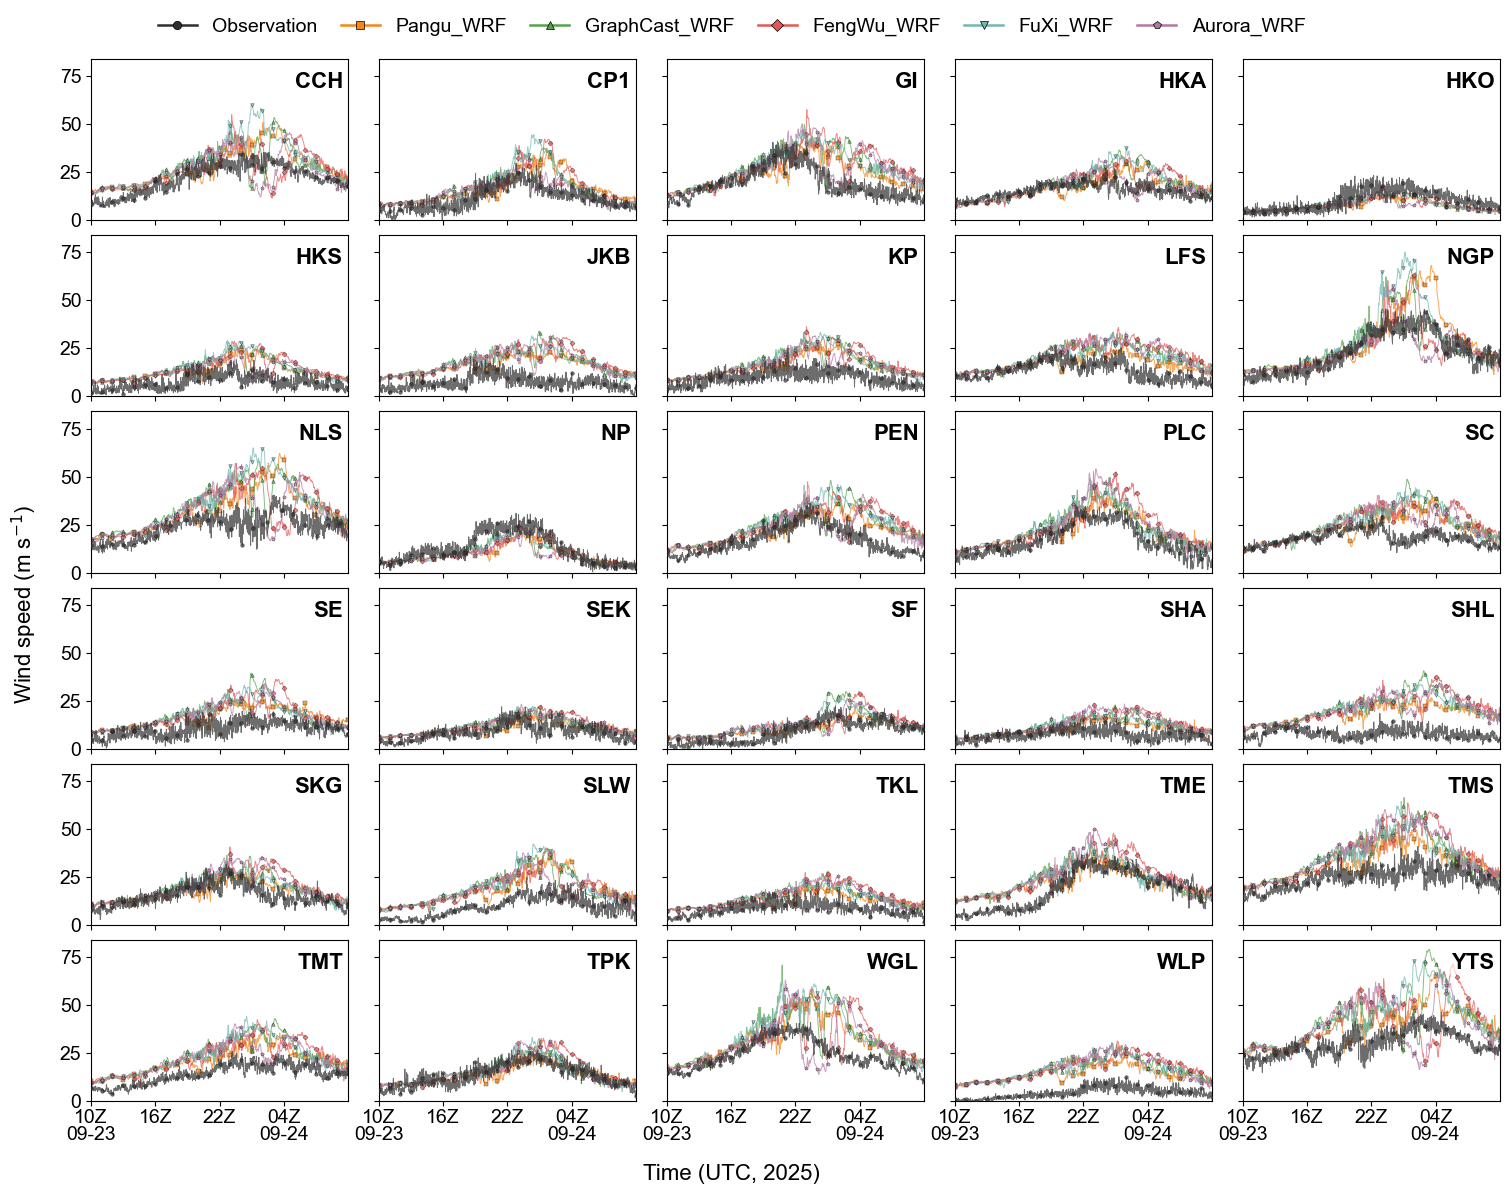

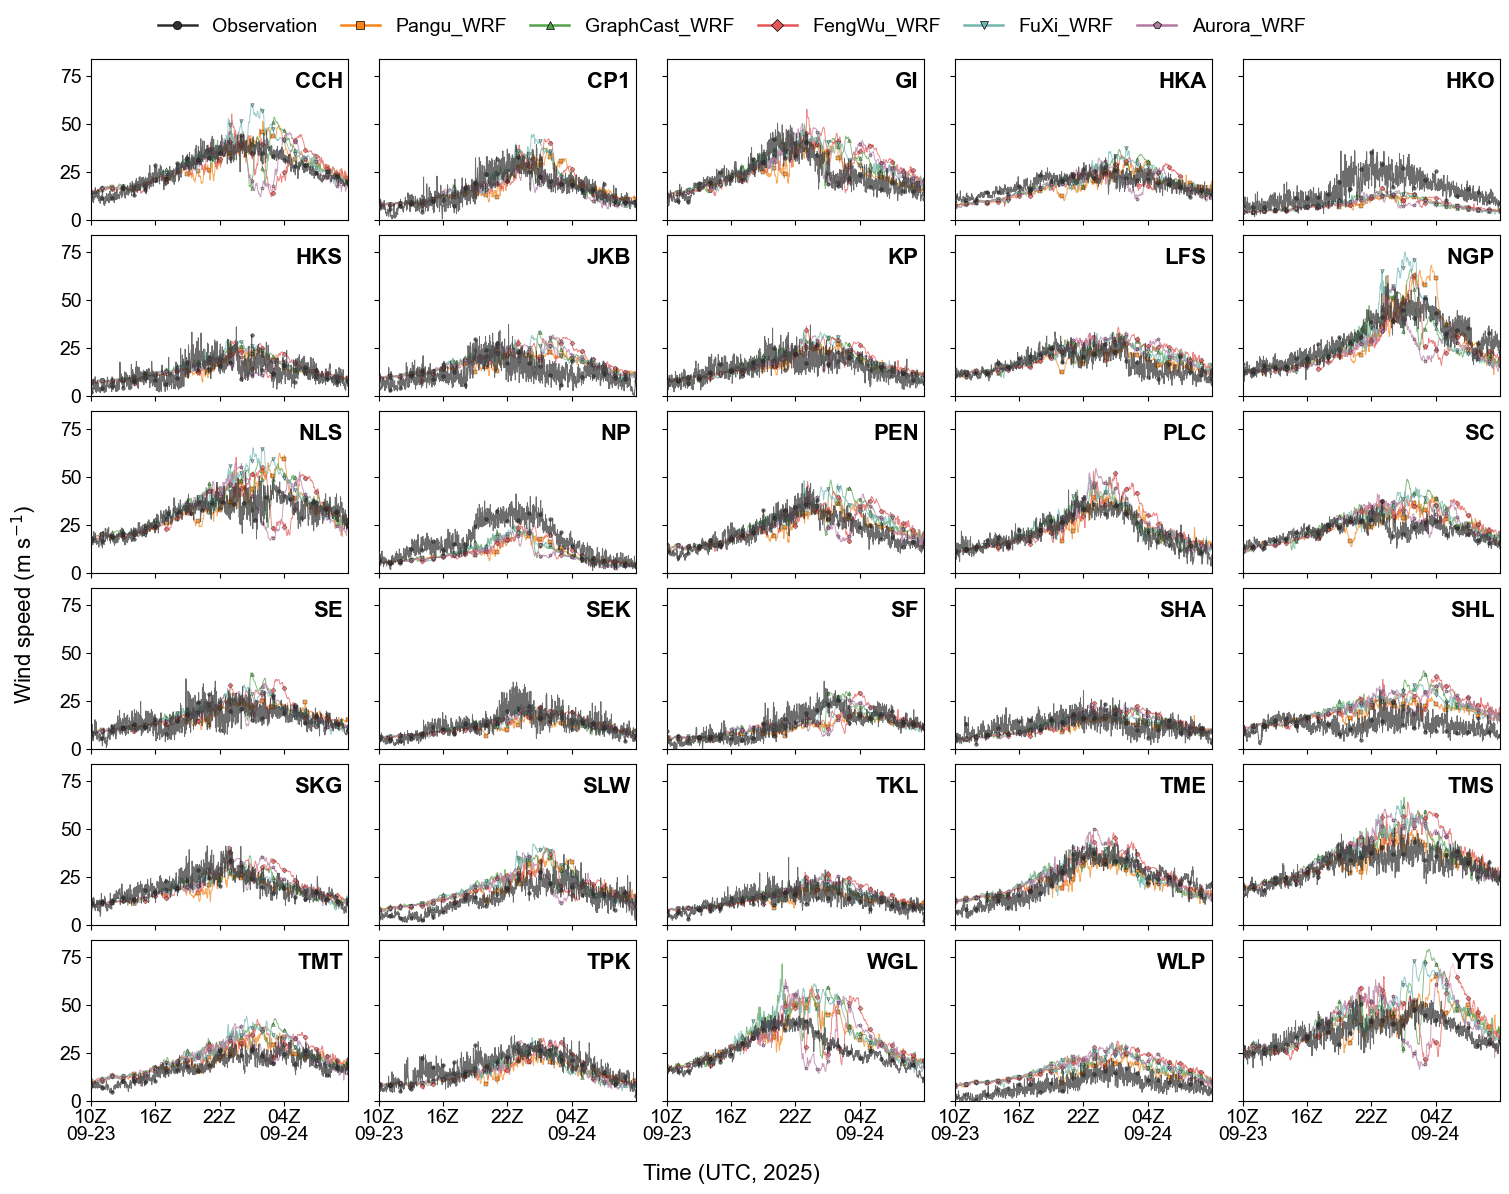

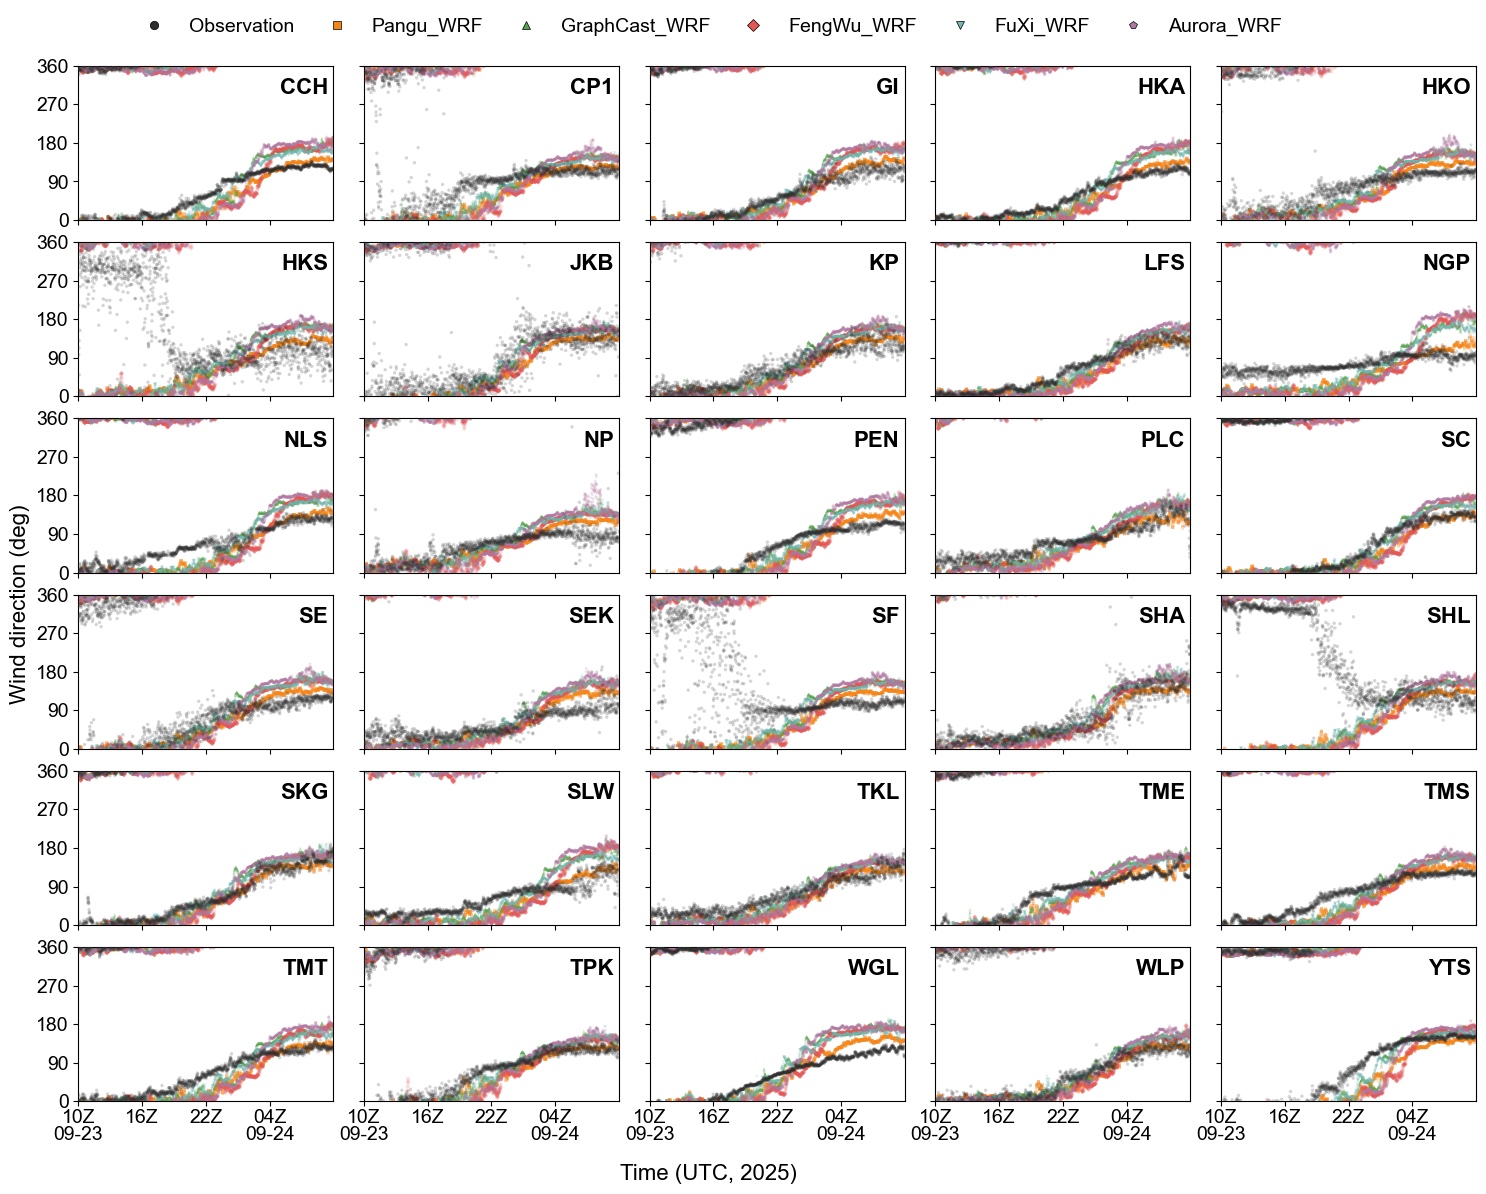

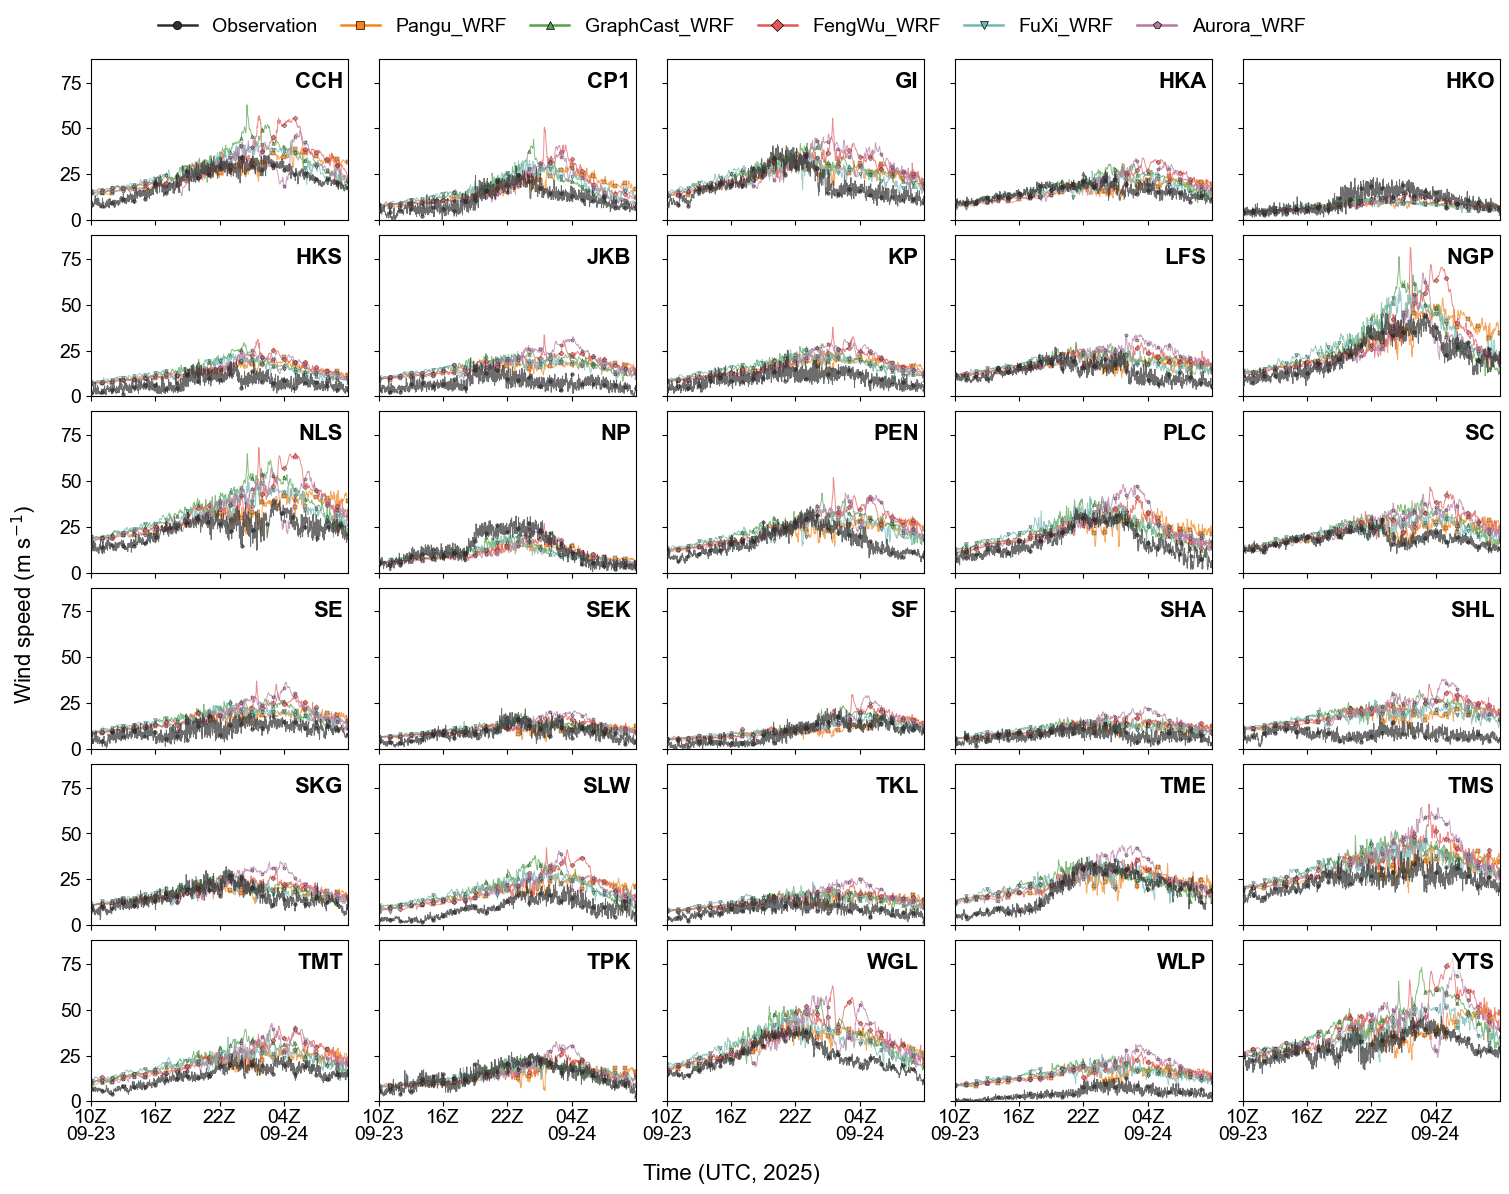

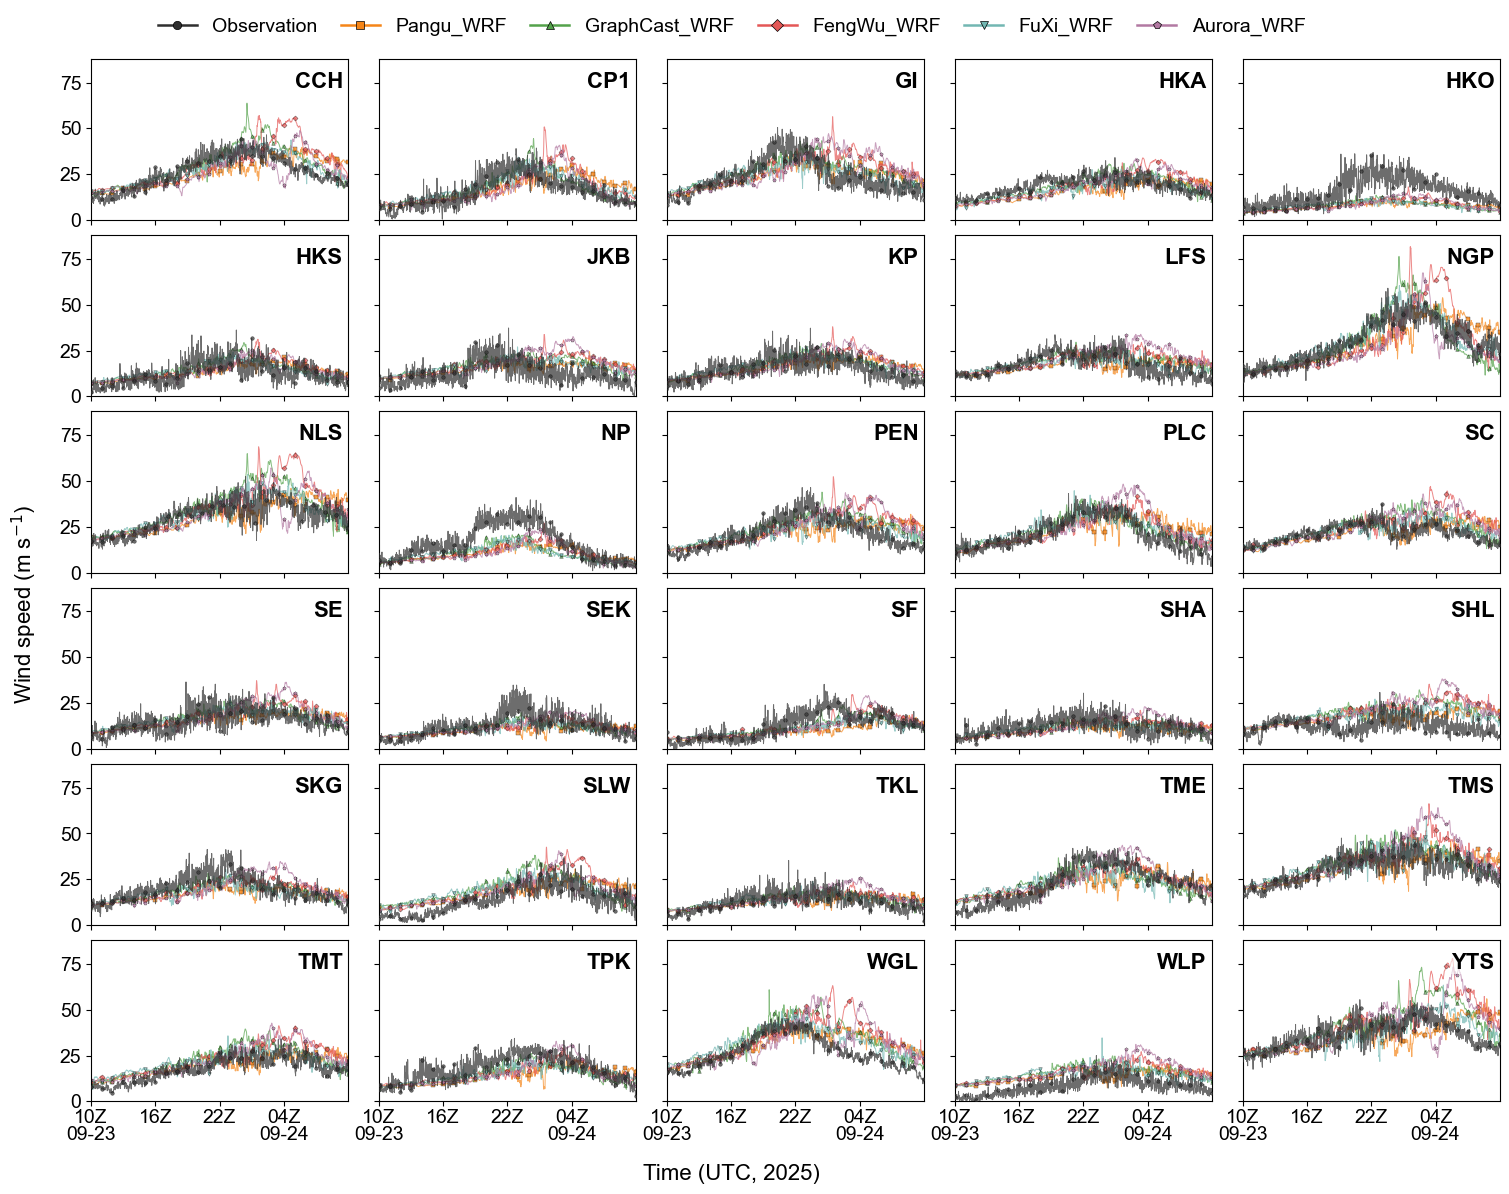

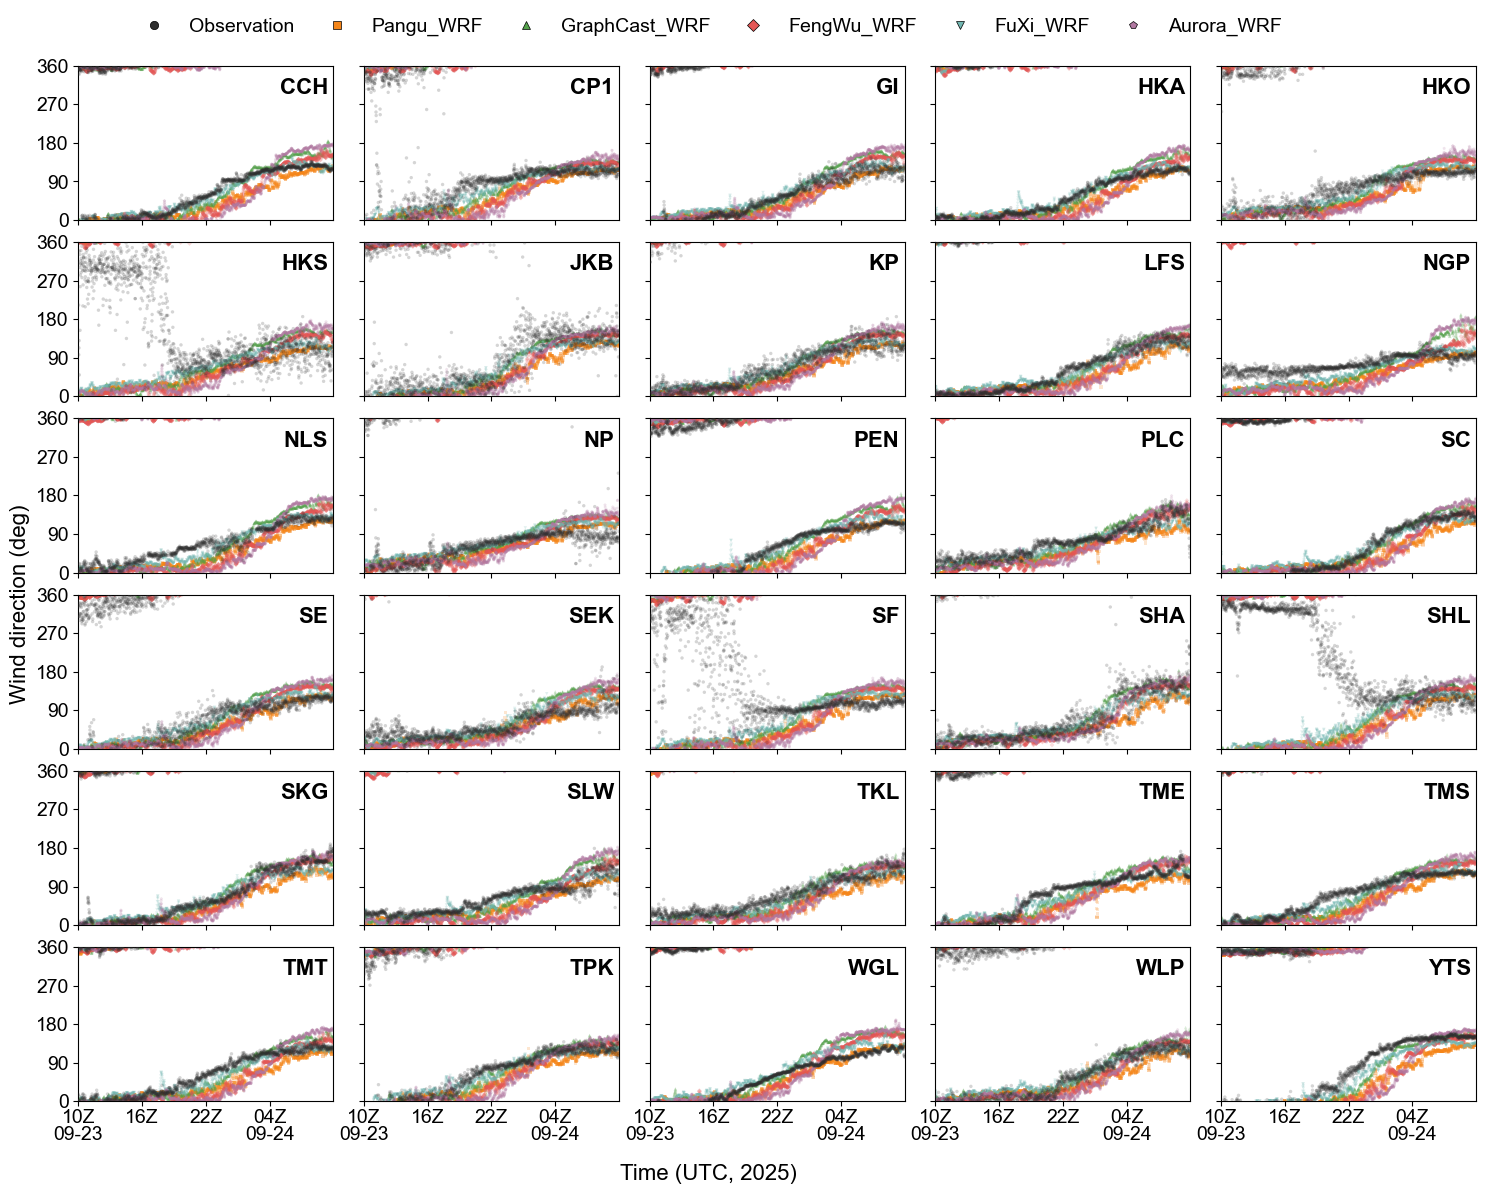

Saved files:
24h -> publish\allstations_meanwspd_obs_ai_24h_20250923-10_to_20250924-10.tif
24h -> publish\allstations_maxwspd_obs_ai_24h_20250923-10_to_20250924-10.tif
24h -> publish\allstations_wdir_obs_ai_24h_20250923-10_to_20250924-10.tif
48h -> publish\allstations_meanwspd_obs_ai_48h_20250923-10_to_20250924-10.tif
48h -> publish\allstations_maxwspd_obs_ai_48h_20250923-10_to_20250924-10.tif
48h -> publish\allstations_wdir_obs_ai_48h_20250923-10_to_20250924-10.tif


{'24h': [WindowsPath('publish/allstations_meanwspd_obs_ai_24h_20250923-10_to_20250924-10.tif'),
  WindowsPath('publish/allstations_maxwspd_obs_ai_24h_20250923-10_to_20250924-10.tif'),
  WindowsPath('publish/allstations_wdir_obs_ai_24h_20250923-10_to_20250924-10.tif')],
 '48h': [WindowsPath('publish/allstations_meanwspd_obs_ai_48h_20250923-10_to_20250924-10.tif'),
  WindowsPath('publish/allstations_maxwspd_obs_ai_48h_20250923-10_to_20250924-10.tif'),
  WindowsPath('publish/allstations_wdir_obs_ai_48h_20250923-10_to_20250924-10.tif')]}

In [9]:
# --- Generate figures (24h then 48h) ---

outputs: dict[str, list[Path]] = {"24h": [], "48h": []}

# 24h lead time
outputs["24h"].append(plot_allstations_speed("mean_wspd", lead="24h", file_tag="meanwspd"))
outputs["24h"].append(plot_allstations_speed("max_wspd", lead="24h", file_tag="maxwspd"))
outputs["24h"].append(plot_allstations_wdir("mean_wdir", lead="24h", file_tag="wdir"))

# 48h lead time
outputs["48h"].append(plot_allstations_speed("mean_wspd", lead="48h", file_tag="meanwspd"))
outputs["48h"].append(plot_allstations_speed("max_wspd", lead="48h", file_tag="maxwspd"))
outputs["48h"].append(plot_allstations_wdir("mean_wdir", lead="48h", file_tag="wdir"))

print("Saved files:")
for lead, paths in outputs.items():
    for p in paths:
        print(lead, "->", p)

outputs
